# Customer segmentation with RFM and K-Means clustering
---

<div style="padding:10px; border-radius:5px; background-color:#dfe6e2">
<b>Objective:</b> The objective of this notebook is to segment customers based on <code>Recency</code>, <code>Frequency</code>, and <code>Monetary</code>value in order to identify high-value, loyal, and at-risk customers and support churn prevention strategies. 
</div>


## Introduction
[Fecom Inc.](https://www.kaggle.com/datasets/cemeraan/fecom-inc-e-com-marketplace-orders-data-crm/data) is a growing, Berlin-based e-commerce marketplace with an expanding customer base, making customer segmentation increasingly important for data-driven decision-making.

This notebook focuses on customer behavior analysis within the broader Fecom Inc. e-commerce analytics project. While the main dashboard provides a consolidated view of overall marketplace performance, it does not fully explain how customers behave over time or which customer segments drive value and retention.

This analysis applies RFM segmentation (Recency, Frequency, Monetary) to:
- Quantify how recently and how often customers purchase
- Distinguish high-value and loyal customers from one-time buyers
- Identify customer segments at risk of churn
- Provide a foundation for retention and re-engagement strategies

⭐**The results of this notebook are intended to complement the Power BI dashboards by offering customer-level segmentation that can be translated into targeted business actions.**

## Key Components of RFM Analysis
RFM analysis provides insights into different levels of customer engagement and loyalty, enabling targeted strategies for retention and growth
<div style="background-color: #d0e7ff; padding: 10px; border-radius: 5px;">  
<strong>Recency:</strong> Shows how long it has been since a customer’s last purchase.<br>
Customers who purchased recently are usually more valuable because they are more likely to buy again soon.
</div>

<div style="background-color: #e8d9ff; padding: 10px; border-radius: 5px;">
<strong>Frequency:</strong> Indicates how often a customer makes purchases over a certain period.<br>
High frequency suggests strong loyalty to the brand or product.
</div>

<div style="background-color: #fff9c4; padding: 10px; border-radius: 5px;">
<strong>Monetary:</strong> Measures the total amount a customer has spent over a given period.<br>
Higher spending indicates greater value of the customer to the business.
</div>

## Why K-Means?

K-Means Clustering is an Unsupervised Machine Learning algorithm that groups customers based on similarity. K-Means was chosen for its **simplicity, speed,** and **effectiveness** in segmenting large customer datasets. 

Key advantages of K-Means include:

- Compared to other clustering methods, **K-Means is computationally fast** and requires only one key parameter, the number of clusters. This makes it straightforward to apply and interpret for business purposes.

- Using K-Means in combination with RFM metrics provides a **practical and repeatable framework** for customer segmentation that
**can be updated regularly with new transaction data**. It supports ongoing strategy for targeted promotions, personalized offers, and customer retention campaigns.

- The clustering allows **uncovering hidden patterns in customer behavior** that may not be evident from aggregate statistics.

---

## 🔵  Step 1: Setup & Imports <a name="Step 1: Setup & Imports"></a>

Uncomment and run to install `psycopg2-binary` if not already available to enable PostgreSQL connection:

In [1]:
# psycopg2-binary needed for PostgreSQL connection
# !pip install psycopg2-binary

In [2]:
import pandas as pd                         # Data manipulation and analysis
import numpy as np                          # Numerical operations 

from config import DB_CONFIG                # Local database credentials (excluded from GitHub)
from sqlalchemy import create_engine        # Database connection engine

import matplotlib.pyplot as plt             # Base plotting library
import seaborn as sns                       # Statistical visualisations

from sklearn.preprocessing import StandardScaler  # Standardize features
from sklearn.cluster import KMeans                # KMeans clustering 
from sklearn.metrics import silhouette_score      # Evaluate cluster quality
from sklearn.metrics import adjusted_rand_score, v_measure_score # Metrics for comparing clusterings
import itertools                                  # Tool for creating label pairs

This block connects to the local **PostgreSQL** database using credentials stored securely in `config.py` and load relevant RFM data (subscriber ID, order date, and monetary value) into a pandas DataFrame:

In [3]:
# Connect to local PostgreSQL database
engine = create_engine(
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}@"
    f"{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)
# SQL query to select necessary columns
query = """
-- RFM data for each subscriber
SELECT
    cl.subscriber_id,                                    -- Unique customer identifier
    o.order_id,
    o.order_purchase_timestamp::date AS order_date,      -- Purchase date
    COALESCE(SUM(op.payment_value), 0) AS monetary      -- Total payment amount per order
FROM customer_list cl
JOIN orders o 
    ON o.customer_trx_id = cl.customer_trx_id
JOIN order_payments op
    ON op.order_id = o.order_id
WHERE o.order_status NOT IN ('canceled') AND o.order_purchase_timestamp::date <= '2024-08-31' AND o.order_purchase_timestamp::date >= '2023-01-31'             -- Exclude canceled orders
GROUP BY cl.subscriber_id, o.order_id, o.order_purchase_timestamp::date
ORDER BY cl.subscriber_id, order_date;
"""
# Load data into a pandas DataFrame
rfm_data = pd.read_sql(query, engine)

RFM data successfully loaded into DataFrame. Ready for preprocessing.

## 🔵  Step 2: Data Cleaning & Preparation 

This step focuses on cleaning and preparing the data for aggregation into **Recency**, **Frequency**, and **Monetary** metrics.  
Key tasks:  
- Convert order dates to datetime  
- Check and handle missing values  
- Ensure numeric columns are properly typed

In [4]:
# Quick look at the data
rfm_data.head() 

,subscriber_id,order_id,order_date,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2024-05-10,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2024-05-07,27.19
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2023-03-10,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2023-10-12,43.62
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2023-11-14,196.89


Let's check the dataset for data types and missing values:

In [5]:
# Check data types and missing values
rfm_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97785 entries, 0 to 97784
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subscriber_id  97785 non-null  object 
 1   order_id       97785 non-null  object 
 2   order_date     97785 non-null  object 
 3   monetary       97785 non-null  float64
dtypes: float64(1), object(3)
memory usage: 3.0+ MB


Notes:
- All three columns are complete. No missing values
- `order_date` needs conversion to datetime

We convert `order_date` to datetime to accurately calculate the **Recency** metric in RFM analysis:

Convert the `order_date` column to datetime for proper calculations

In [6]:
# Convert the order_date to datetime 
rfm_data['order_date'] = pd.to_datetime(rfm_data['order_date'])

Check for duplicate rows to ensure each transaction is unique before aggregation:

In [7]:
# Check for duplicates
rfm_data.duplicated().sum()

np.int64(0)

Next, we examine how many orders each customer has made. Customers with 5 or more orders are grouped together to simplify the visualization and highlight the overall purchase frequency distribution.

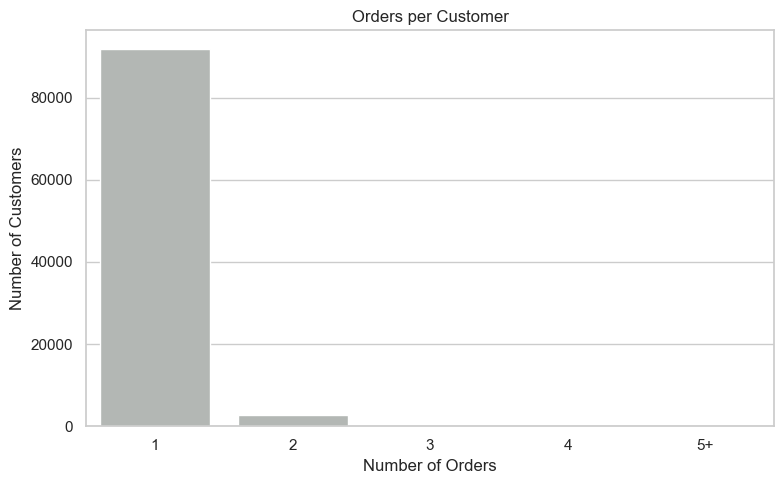

In [8]:
# Count orders per customer
order_counts = rfm_data.groupby('subscriber_id').size().reset_index(name='order_count')

# Group rare high values (5 or more orders)
order_counts['order_count_group'] = order_counts['order_count'].apply(
    lambda x: str(x) if x < 5 else '5+'
)

# Count customers in each order group
order_summary = (
    order_counts['order_count_group']
    .value_counts()
    .sort_index()
    .reset_index()
)
order_summary.columns = ['order_count', 'num_customers']

# Bar chart
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.barplot(
    data=order_summary,
    x='order_count',
    y='num_customers',
    color='#b2b8b4'
)

plt.title('Orders per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()


**Observation:** Most customers made only one order (92 552 customers), indicating a high share of one-time buyers.

To make the distribution easier to interpret, we’ll summarize the number of orders per customer in a table and include the percentage of customers in each group:

In [9]:
# Count orders per customer
order_counts = rfm_data.groupby('subscriber_id').size().reset_index(name='order_count')

# Group rare high values (5+ orders)
order_counts['order_count_group'] = order_counts['order_count'].apply(lambda x: str(x) if x < 5 else '5+')

# Count customers per group
order_summary = order_counts['order_count_group'].value_counts().sort_index().reset_index()
order_summary.columns = ['Number of Orders', 'Number of Customers']

# Add percentage
total_customers = order_summary['Number of Customers'].sum()
order_summary['Percentage'] = (order_summary['Number of Customers'] / total_customers * 100).round(2)

# Display the table
order_summary

,Number of Orders,Number of Customers,Percentage
0,1,91742,96.97
1,2,2638,2.79
2,3,178,0.19
3,4,29,0.03
4,5+,18,0.02


<div style="padding:10px; border-radius:5px; border:2px solid #dfe6e2; background-color:transparent">
<strong>💡Business insight:</strong>
Most customers (97.65%) only place one order. This means the vast majority of customer base is not returning, which signals low retention.
Very few customers (about 2%–0.2%) place multiple orders. These are potentially loyal or high-value customers.<div>
<strong>Implication:</strong> Focus retention efforts on turning one-time buyers into repeat customers. It’s generally cheaper to retain existing customers than to acquire new ones.
</div>


We’ll visualize the distribution of order amounts to understand how monetary values are spread across all transactions. 

**Note:** The y-axis uses a log scale to make both common low-value orders and rare high-value orders visible, since a linear scale would compress the majority of data and hide extreme values.

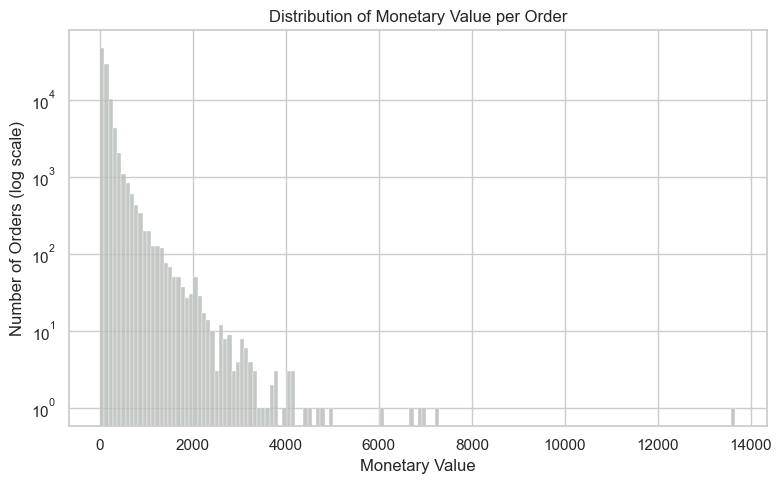

In [10]:
# Create a histogram of order monetary values
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.histplot(
    rfm_data['monetary'],
    bins=150,
    color='#b2b8b4'
)

# Use log scale on Y-axis to highlight both frequent and rare high-value orders
plt.yscale('log')

plt.title('Distribution of Monetary Value per Order')
plt.xlabel('Monetary Value')
plt.ylabel('Number of Orders (log scale)')

plt.tight_layout()
plt.show()


Let’s get a quick statistical overview of the monetary values to understand the typical order value and spot extreme transactions

In [11]:
rfm_data.monetary.describe()

count    97785.000000
mean       160.416022
std        220.210665
min          9.590000
25%         62.010000
50%        105.280000
75%        176.650000
max      13664.080000
Name: monetary, dtype: float64

<div style="padding:10px; border-radius:5px; border:2px solid #f5a747; background-color:transparent">
⚠️The maximum value is extremely high (≈13.7k), which indicates strong outliers that could skew analysis.
</div>

<div style="padding:10px; border-radius:5px; border:2px solid #dfe6e2; background-color:transparent">
<strong> Decision:</strong> We’ll handle these extreme values by identifying top spenders as VIPs. They will be excluded from the clustering process because KMeans is sensitive to outliers, which can distort cluster centers. We’ll apply this after calculating the Recency, Frequency, and Monetary metrics in the next steps.
</div>

## 🔵  Step 3: Calculating RFM Metrics

In this step, we will compute the Recency, Frequency, and Monetary values for each customer to quantify their engagement and spending behavior.

In [12]:
# Calculate Recency, Frequency, Monetary for each customer
reference_date = pd.to_datetime('2024-09-01')

rfm = rfm_data.groupby('subscriber_id').agg({
    'order_date': lambda x: (reference_date - x.max()).days,  # Recency: days since last order
    'subscriber_id': 'count',                                # Frequency: number of orders
    'monetary': 'sum'                                        # Monetary: total spent
}).rename(columns={
    'order_date': 'Recency',
    'subscriber_id': 'Frequency',
    'monetary': 'Monetary'
}).reset_index()

Let’s take a quick look at the first few rows of our RFM table

In [13]:
# Quick look at the data
rfm.head()

,subscriber_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,114,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,117,1,27.19
2,0000f46a3911fa3c0805444483337064,541,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,325,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,292,1,196.89


Frequency is mostly 1 for the majority of customers, so it doesn’t contribute much to distinguishing between them in this analysis.

Before clustering, we’ll **isolate the top spenders as VIP customers**. This helps ensure the clusters capture the behavior of the typical customer base more accurately, without being skewed by extreme values. We will add the VIPs back into the final results after clustering.

In [14]:
# Define VIP threshold as the 99.5th percentile of Monetary
vip_threshold = rfm['Monetary'].quantile(0.995)

# Assign segments
rfm['Segment'] = 'Regular'
rfm.loc[rfm['Monetary'] >= vip_threshold, 'Segment'] = 'VIP'

## 🔵  Step 4: Transform & Scale for KMeans

In this step, we’ll scale the data because KMeans relies on distances between points and centroids. Without scaling, variables with larger ranges would dominate the clustering, and the algorithm wouldn’t account properly for differences in units across features.

Let’s check the distributions of `Recency`, `Frequency`, and `Monetary` to see if they are skewed

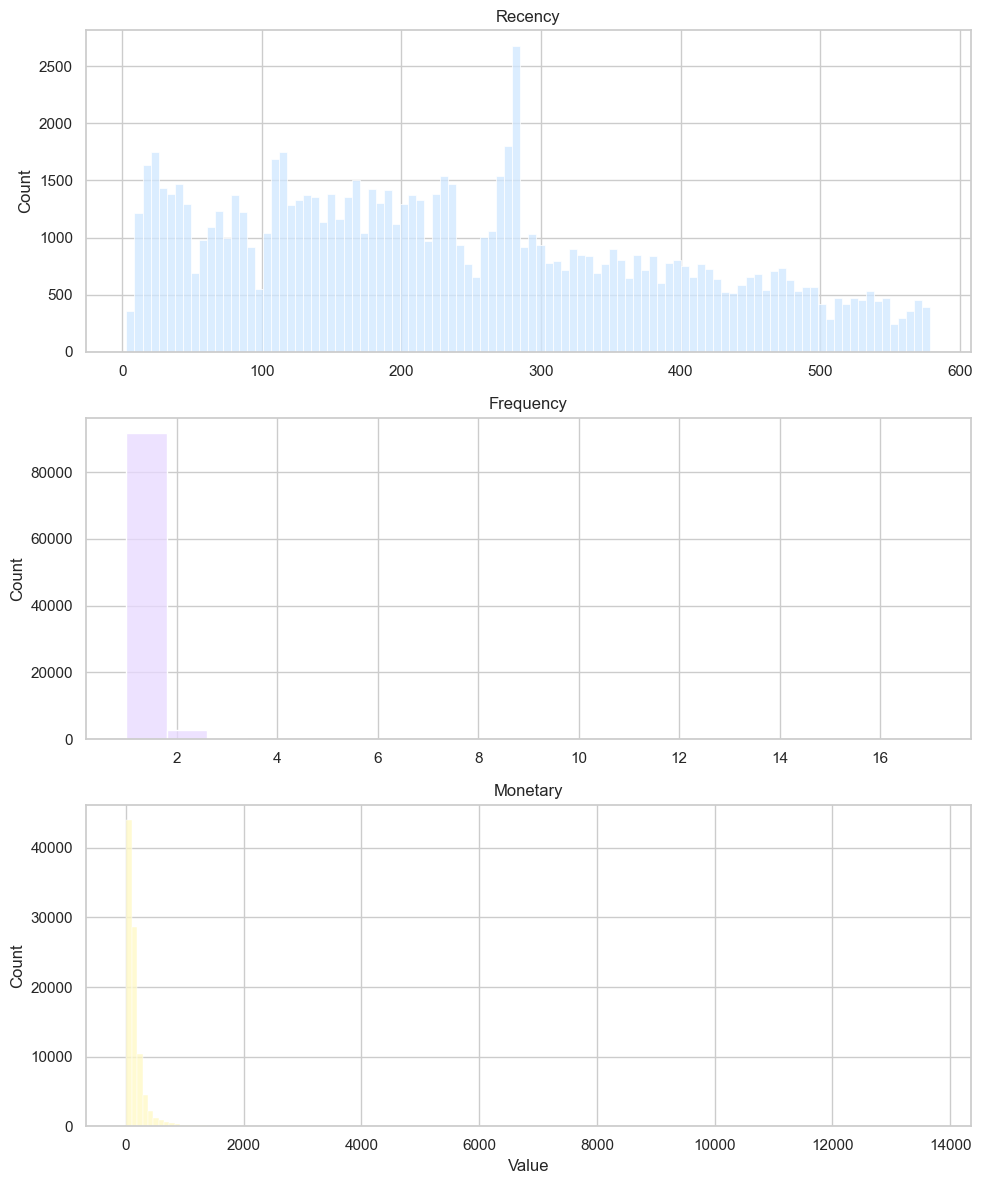

In [15]:
# Create a figure with 3 subplots for RFM features
sns.set(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Recency
sns.histplot(rfm['Recency'], bins=100, color='#d0e7ff', kde=False, ax=axes[0])
axes[0].set_title('Recency')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')

# Frequency
sns.histplot(rfm['Frequency'], bins=20, color='#e8d9ff', kde=False, ax=axes[1])
axes[1].set_title('Frequency')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')

# Monetary
sns.histplot(rfm['Monetary'], bins=150, color='#fff9c4', kde=False, ax=axes[2])
axes[2].set_title('Monetary')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Count')

plt.tight_layout()

# Display 
plt.show()

The histograms reveal that `Monetary` and `Frequency` are highly skewed, with most customers having low values and a small number of extreme cases. `Recency` is fairly evenly distributed, with only a slight decrease at higher values.


<div style="padding:10px; border-radius:5px; border:2px solid #f5a747; background-color:transparent">
⚠️K-means determines similarity based on the distance between data points and cluster centroids, so scaling is essential. Without scaling, features with larger numeric ranges could dominate the distance calculation, since the algorithm doesn’t automatically account for the units of each variable.
</div>

Finally, we apply a log transformation to the highly skewed `Frequency` and `Monetary` features, and then standardize all RFM columns using **StandardScaler** 

In [16]:
# Separate VIP customers (top 0.5% by Monetary)
cap = rfm['Monetary'].quantile(0.995)
vip_customers = rfm[rfm['Monetary'] > cap].copy()       # VIPs
rfm_main = rfm[rfm['Monetary'] <= cap].copy()           # main customers

# Apply logarithm to RFM values to reduce the impact of extreme values for main customers
rfm_main['Monetary_log'] = np.log1p(rfm_main['Monetary'])
rfm_main['Frequency_log'] = np.log1p(rfm_main['Frequency'])
#rfm_main['Recency_log'] = np.log1p(rfm_main['Recency'])

# Standardize features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_main[['Recency', 'Frequency_log', 'Monetary_log']])

## 🔵  Step 5: Model Training

In this step, we train the K-Means clustering model to segment customers, using `k-means++` initialization for improved starting centroids.

In [17]:
# K-Means clustering on main customers (excluding VIPs)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=25, n_init=15) # n_init=15 to achieve consistent clustering results 
rfm_main['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Average RFM values per cluster for interpretation
cluster_summary = rfm_main.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(cluster_summary)

            Recency  Frequency    Monetary
Cluster                                   
0        375.535258   1.000000  281.073238
1        134.768509   1.000000   62.585400
2        221.303105   2.107622  288.296538
3        391.523657   1.000000   71.415338
4        126.494341   1.000000  236.093955


In [18]:
# Add VIPs back as a separate cluster
vip_customers['Cluster'] = 'VIP'
# Combine main customers and VIPs into one final table
rfm_final = pd.concat([rfm_main, vip_customers], ignore_index=True)
# Quick look at the data
rfm_final.head()

,subscriber_id,Recency,Frequency,Monetary,Segment,Monetary_log,Frequency_log,Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,114,1,141.90,Regular,4.962145,0.693147,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,117,1,27.19,Regular,3.338967,0.693147,1
2,0000f46a3911fa3c0805444483337064,541,1,86.22,Regular,4.468434,0.693147,3
3,0000f6ccb0745a6a4b88665a16c9f078,325,1,43.62,Regular,3.798182,0.693147,3
4,0004aac84e0df4da2b147fca70cf8255,292,1,196.89,Regular,5.287711,0.693147,0


## 🔵  Step 6: Choosing the Optimal Number of Clusters

We now move on to selecting the optimal number of clusters, using **Inertia** and **Silhouette Score** to guide our decision.

* **Inertia** measures how tightly grouped the observations are around their cluster centroids. We often use the **elbow method** to find the point where adding more clusters only marginally reduces inertia.

* **Silhouette Score** complements inertia by considering both how close points are to their own cluster (cohesion) and how far they are from the nearest other cluster (separation). Scores closer to 1 indicate well-defined clusters.

Together, these metrics help determine the number of clusters that best capture the structure in the data without overfitting.

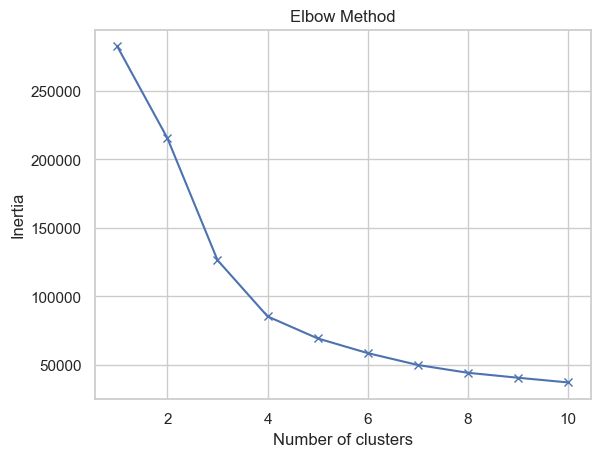

In [19]:
# Elbow method: plot inertia for different k to find the optimal number of clusters
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=25).fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

By evaluating cluster quality with the Silhouette Score, we can ensure that each group is well-separated and meaningful, reducing the risk of misclassification and enabling confident data-driven decisions.

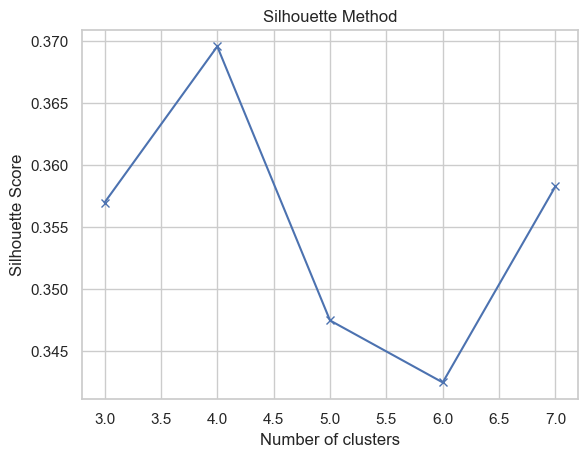

In [20]:
# This block may take up to ~15 minutes to run
# Uncomment only if recomputation is needed
#"""
# Silhouette method: check cluster quality, higher score = better separation
scores = []
for k in range(3, 8):
    kmeans = KMeans(n_clusters=k, random_state=25).fit(rfm_scaled)
    score = silhouette_score(rfm_scaled, kmeans.labels_)
    scores.append(score)

plt.plot(range(3, 8), scores, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show() #"""

<div style="padding:10px; border-radius:5px; border:2px solid #dfe6e2; background-color:transparent">
💡Considering the elbow method and silhouette scores, and balancing interpretability with business goals, <strong>5 clusters</strong> were selected to provide nuanced segmentation and actionable insights into customer behavior.
</div>

## 🔵  Step 7: Final Model & Visualize Segments

Calculates the mean `Recency`, `Frequency`, and `Monetary` values for each cluster, helping interpret customer segments and their purchasing behavior

In [21]:
# Average RFM values per cluster
rfm_main.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,375.535258,1.000000,281.073238
1,134.768509,1.000000,62.585400
2,221.303105,2.107622,288.296538
3,391.523657,1.000000,71.415338
4,126.494341,1.000000,236.093955


Assign descriptive names to each cluster in **the final model with the optimal k** to make customer segments more interpretable.

In [22]:
# Create a mapping from cluster numbers to descriptive names
cluster_names = {
    0: 'Inactive High Spenders',
    1: 'Recent Low Spenders',
    2: 'Loyal Spenders',
    3: 'Inactive Low Spenders',
    4: 'Recent High Spenders',
    'VIP': 'VIP Spenders'
}

# Apply the mapping
rfm_final['Cluster_Name'] = rfm_final['Cluster'].map(cluster_names)

# Check the updated DataFrame to verify the segment names
rfm_final[['subscriber_id', 'Cluster', 'Cluster_Name']].head()

,subscriber_id,Cluster,Cluster_Name
0,0000366f3b9a7992bf8c76cfdf3221e2,4,Recent High Spenders
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,Recent Low Spenders
2,0000f46a3911fa3c0805444483337064,3,Inactive Low Spenders
3,0000f6ccb0745a6a4b88665a16c9f078,3,Inactive Low Spenders
4,0004aac84e0df4da2b147fca70cf8255,0,Inactive High Spenders


**Visualize customer segments**

This scatter plot shows the final clusters from the optimal K-Means model. Each cluster is colored distinctly

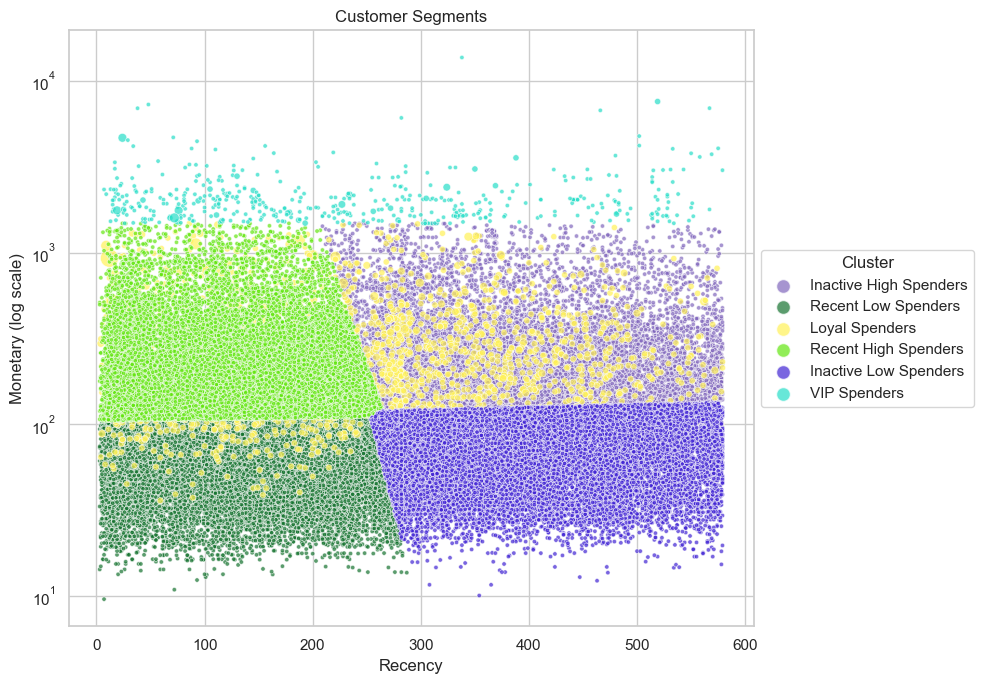

In [23]:
# Define colors for each cluster
colors = {
    'Inactive High Spenders': '#8167bd',
    'Recent Low Spenders': '#15732f',
    'Loyal Spenders': '#fff157',
    'Recent High Spenders': '#62e610',
    'Inactive Low Spenders': '#4124d4',
    'VIP Spenders': '#26dec8'
}

plt.figure(figsize=(10, 7))
sns.set(style="whitegrid")

# Plot each cluster
for cluster, color in colors.items():
    subset = rfm_final[rfm_final['Cluster_Name'] == cluster]
    plt.scatter(
        subset['Recency'], 
        subset['Monetary'], 
        s=subset['Frequency']*10,  # size by frequency
        c=color,
        label=cluster,
        alpha=0.7,                  # transparency
        edgecolors='w',             # white border
        linewidth=0.5
    )

# Log scale for monetary axis
plt.yscale('log')

# Labels and title
plt.xlabel('Recency')
plt.ylabel('Monetary (log scale)')
plt.title('Customer Segments')

# Custom legend with uniform size
handles = [plt.scatter([], [], s=100, color=color, alpha=0.7, edgecolors='w') 
           for color in colors.values()]
plt.legend(handles, colors.keys(), title='Cluster', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()

plt.show()

To understand how customers are distributed across the identified RFM segments, we examine the size of each cluster.

In [24]:
# Count the number of customers in each RFM segment
rfm_final['Cluster_Name'].value_counts()

Cluster_Name
Recent Low Spenders       27055
Recent High Spenders      25270
Inactive Low Spenders     22763
Inactive High Spenders    16209
Loyal Spenders             2834
VIP Spenders                474
Name: count, dtype: int64

Shows the proportion of customers in each cluster as percentages.

In [25]:
cluster_perc = rfm_final['Cluster_Name'].value_counts(normalize=True).mul(100).round(1)

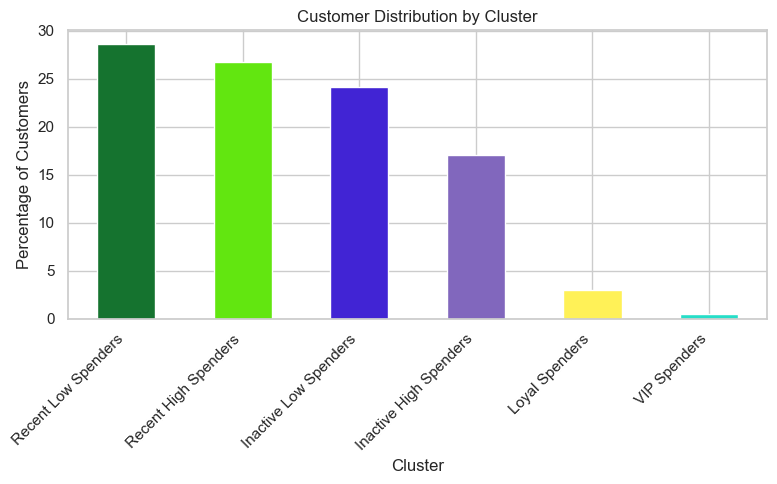

In [26]:
# Get the colors for each cluster in the same order
cluster_colors = [colors[cluster] for cluster in cluster_perc.index]

# Plot a bar chart of customer distribution by cluster
plt.figure(figsize=(8, 5))
cluster_perc.plot(kind='bar', color=cluster_colors)  # removed edgecolor

plt.ylabel('Percentage of Customers')
plt.xlabel('Cluster')
plt.title('Customer Distribution by Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 🔵  Step 8: Cluster Stability Validation

Check the robustness of our 5-cluster solution by running KMeans multiple times with different random states and comparing cluster assignments using `Adjusted Rand Index` (ARI) and `V-Measure`. High similarity across runs indicates stable and reliable clusters

In [27]:
# Store cluster labels from different runs with different random states
cluster_labels = []
random_states = [10, 25, 42, 50, 100]

for rs in random_states:
    # Fit KMeans on scaled RFM data and get cluster labels
    kmeans = KMeans(n_clusters=5, init='k-means++', random_state=rs, n_init=15)
    labels = kmeans.fit_predict(rfm_scaled)  # using scaled data for consistency
    cluster_labels.append(labels)

# Compute ARI for each pair of runs to check cluster stability
ari_scores = []
for a, b in itertools.combinations(cluster_labels, 2):
    ari = adjusted_rand_score(a, b)
    ari_scores.append(ari)

# Print mean ARI
print("Mean ARI between runs:", np.mean(ari_scores))

Mean ARI between runs: 0.9674960226656857


Cluster robustness check confirms that the 5-cluster solution is highly stable. The mean ARI across multiple KMeans runs is 0.97, indicating very consistent cluster assignments despite different random initializations

## 🔵  Step 9: Export Results

Rename columns for clarity and presentation:

In [28]:
appendix_table = rfm_final.rename(
    columns={'subscriber_id': 'Subscriber_ID', 'Cluster_Name': 'Customer_Segment'}
)[['Subscriber_ID', 'Customer_Segment', 'Recency', 'Frequency', 'Monetary']]

In [29]:
# Quick look at the data
appendix_table.head()

,Subscriber_ID,Customer_Segment,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,Recent High Spenders,114,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,Recent Low Spenders,117,1,27.19
2,0000f46a3911fa3c0805444483337064,Inactive Low Spenders,541,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,Inactive Low Spenders,325,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,Inactive High Spenders,292,1,196.89


In [30]:
# Check data types, non-null counts of the final table
appendix_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94605 entries, 0 to 94604
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Subscriber_ID     94605 non-null  object 
 1   Customer_Segment  94605 non-null  object 
 2   Recency           94605 non-null  int64  
 3   Frequency         94605 non-null  int64  
 4   Monetary          94605 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 3.6+ MB


The `appendix_table` table is clean and ready for export.

### 🗃️Export `customer_segments_export.csv`

We export the prepared table to a CSV file to enable easy sharing with stakeholders and facilitate further analysis in tools like Power BI:

In [31]:
# Export the prepared RFM table to CSV
appendix_table.to_csv('customer_segments_export.csv', index=False)

---

# 💡Interpretation & Insights

The following section provides actionable insights for each customer segment identified in the RFM analysis. 
We categorize recommended actions into **three temporal horizons** for planning and execution:

- **Quick wins (1–3 weeks):** Immediate actions to influence customer behavior while engagement is high
- **Mid-term actions (1–3 months):** Initiatives that require some planning or data accumulation, focused on nurturing   
- **Long-term strategies (3–9 months):** Investments in retention, predictive modeling, and loyalty programs to maximize customer lifetime value
 
To make it easier to focus efforts, we use a **Priority scale** to show the relative importance of each segment and guide where resources should be focused:<br>
<span style="background-color:#26c6da;padding:2px 6px;border-radius:4px;">Strategic</span> top-priority clients, requires highest-touch approach<br>
<span style="background-color:#f28b82;padding:2px 6px;border-radius:4px;">Very High</span> must act first, highest impact on revenue and retention  
<span style="background-color:#fbbc04;padding:2px 6px;border-radius:4px;">High</span> significant impact, prioritize after 'Very High'  
<span style="background-color:#fff475;padding:2px 6px;border-radius:4px;">Medium</span> moderate impact, execute tactically with measured effort  
<span style="background-color:#ccff90;padding:2px 6px;border-radius:4px;">Low–Medium</span> limited impact or low-value segments, use cost-efficient approaches<br>
<span style="background-color:#a7ffeb;padding:2px 6px;border-radius:4px;">Low</span> minimal urgency, act only if resources allow

**Note:** The `KPIs` listed for each segment indicate the metrics to monitor the effectiveness of the recommended actions

### Total: 94 605 customers

---
## <span style="color:#15732f">◆ Recent Low Spenders - 27 055 (28.6%)</span> 
ℹ️ New customers making small purchases, with opportunities to encourage repeat buying and increase their spend. Aim to **turn them into repeat buyers** and gradually **increase average order value**.

**Quick wins**  
- Post-purchase emails: “recommended for you” + small coupon / free shipping.  
- Run personalized cross-sell / product-bundle campaigns.  

**Mid-term**  
- Light segmentation by product category to increase relevance.  
- Test different incentive types (discounts, free shipping) to optimize repeat purchase.  

**Long-term**  
- Predictive propensity scoring to identify potential high-value repeat buyers.  

**KPIs:** `2nd purchase conversion` | `Revenue per customer` | `Cross-sell email conversion rate`<br> 
**Priority:** <span style="background-color:#fff475;padding:2px 6px;border-radius:4px;">Medium</span>

---

## <span style="color:#62e610">◆ Recent High Spenders - 25 270 (26.7%)</span>
ℹ️ New customers spending more than average, with potential to convert into repeat buyers and drive short-term revenue. Focus on **converting them into loyal repeat buyers** and **increasing their lifetime value**.

**Quick wins**  
- Loyalty points or early access campaigns.  
- Value-based offers (bundles, service upgrades) instead of heavy discounts.  

**Mid-term**  
- Solicit feedback / encourage reviews to increase lifetime value and referrals.  
- Personalized product recommendations to increase AOV.  

**Long-term**  
- Build predictive retention models for high-value buyers.  

**KPIs:** `Retention rate` | `Repeat frequency` | `CLV` | `Margin per customer`  
**Priority:** <span style="background-color:#fbbc04;padding:2px 6px;border-radius:4px;">High</span>

---

## <span style="color:#4124d4">◆ Inactive Low Spenders - 22 763 (24.1%)</span>
ℹ️ Customers who spent little and haven’t returned recently, with some potential to reactivate at low cost per person. **Try to bring them back cost-effectively** while keeping ROI in mind.

**Quick wins**  
- Low-cost win-back campaigns: remarketing, timed discount codes, reactivation drip via email/SMS.  

**Mid-term**  
- Test cheap incentives (10% off) and measure reactivation vs. cost.  
- Move to low-cost lifecycle streams: newsletters, low-frequency campaigns.  

**Long-term**  
- Predictive churn models to identify the most likely to reactivate efficiently.  

**KPIs:** `Reactivation rate` | `Cost per reactivation` | `Revenue per customer`  
**Priority:** <span style="background-color:#ccff90;padding:2px 6px;border-radius:4px;">Low–Medium</span>

---

## <span style="color:#8167bd">◆ Inactive High Spenders - 16 209 (17.1%)</span>
ℹ️ Customers who used to spend a lot but haven’t bought recently, making them high-priority for reactivation. Focus on **recovering lost high-value revenue** through targeted reactivation efforts.

**Quick wins**  
- High-touch outreach: personalized email + SMS, time-limited premium offers.  

**Mid-term**  
- Dedicated account management / concierge offers for top 10% of this segment.  
- Run exit surveys / feedback loops; A/B test recovery offers.  

**Long-term**  
- Build predictive models to prevent future lapses among high-value customers.  

**KPIs:** `Reactivation rate` | `Revenue recovered` | `Cost per recovered customer` | `Churn rate`  
**Priority:** <span style="background-color:#f28b82;padding:2px 6px;border-radius:4px;">Very High</span>

---

## <span style="color:#e6d627">◆ Loyal Spenders - 2 834 (3%)</span>
ℹ️ Customers who buy often and spend a lot, forming a small but crucial group for sustaining long-term revenue. **Maintain engagement**, **maximize repeat purchases**, and **strengthen loyalty**.

**Quick wins**  
- Exclusive benefits and loyalty tiers; early product access.  

**Mid-term**  
- Build referral and advocacy programs.  
- Monitor satisfaction (NPS) and protect margins (avoid blanket discounts).  

**Long-term**  
- Predictive modeling for retention and CLV optimization.  

**KPIs:** `Churn rate (loyal group)` | `Average orders per period` | `Referral conversions` | `CLV`  
**Priority:** <span style="background-color:#f28b82;padding:2px 6px;border-radius:4px;">Very High</span>

---

## <span style="color:#26dec8">◆ VIP Spenders - 474 (0.5%)</span>
ℹ️ Customers in the top 0.5% of spend, very few in number but delivering exceptional value, requiring a strategic focus. **Ensure high-touch engagement** 
 
**Quick wins**  
- Personal outreach and dedicated offers.  
- White-glove service and curated experiences.  

**Mid-term**  
- Track revenue share and optimize communication cadence.  
- Keep VIPs out of mass campaigns to preserve exclusivity.  

**Long-term**  
- Predictive retention and high-touch personalization to maximize ROI per VIP.  

**KPIs:** `Revenue share` | `Retention rate` | `Satisfaction metrics` | `Margin per customer` <br>
**Priority:** <span style="background-color:#26c6da;padding:2px 6px;border-radius:4px;">Strategic</span>

---

## Key Actions Across Segments
- Reactivate **Inactive High Spenders** 
- Upsell **Recent Low Spenders** through targeted experiments 
- **Loyal High Spenders** and **VIP Spenders** should avoid aggressive discounting and be offered exclusive perks

⚠️ Monitor and Control:  
- Track reactivation cost vs. revenue recovered and monitor CLV changes by cohort <br>
- Define CAC/CPA limits and ensure campaigns remain cost-effective